In [ ]:
# ==============================================================================
# 1. SETUP: IMPORT LIBRARIES
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ==============================================================================
# 2. MODEL IMPLEMENTATION: CLASSES FOR GAME, AGENTS, AND SIMULATION
# ==============================================================================

class BatesonGame:
    """
    Encapsulates the static environment of the Bateson Game, including the
    payoff matrix and methods to verify its axiomatic structure.
    """
    def __init__(self):
        self.frames = ['f1', 'f2']
        self.actions = ['Obey', 'Disobey', 'Question']
        self.substantive_actions = ['Obey', 'Disobey']

        # Payoff matrix from the paper's computational analysis section.
        # Structure: payoffs[frame][action] = (receiver_payoff, sender_payoff)
        self.payoffs = {
            'f1': {
                'Obey': (10, 1),
                'Disobey': (-10, 0),
                'Question': (-5, -5)
            },
            'f2': {
                'Obey': (-10, 10),
                'Disobey': (10, 1),
                'Question': (-5, -5)
            }
        }

    def get_payoffs(self, frame, action):
        """Returns the (receiver, sender) payoff tuple for a given frame and action."""
        return self.payoffs[frame][action]

    def verify_axioms(self):
        """Runs all axiom verification methods and prints the results."""
        print("--- Verifying Bateson Game Axioms ---")
        ax1 = self._verify_axiom_1()
        ax2 = self._verify_axiom_2()
        ax3 = self._verify_axiom_3()
        if all([ax1, ax2, ax3]):
            print("\nAll axioms successfully verified. The environment is a valid Bateson Game.")
        else:
            print("\nOne or more axioms failed. The environment is not a valid Bateson Game.")
        print("-" * 35)

    def _verify_axiom_1(self):
        """Verifies Axiom 1: Frame-Contingent Best-Response Reversal."""
        br_f1 = max(self.substantive_actions, key=lambda a: self.payoffs['f1'][a])
        br_f2 = max(self.substantive_actions, key=lambda a: self.payoffs['f2'][a])
        is_verified = br_f1!= br_f2
        print(f"Axiom 1 (Best-Response Reversal): {'VERIFIED' if is_verified else 'FAILED'}")
        return is_verified

    def _verify_axiom_2(self):
        """Verifies Axiom 2: Meta-Communication Penalty."""
        for frame in self.frames:
            if self.payoffs[frame]['Question'] >= max(self.payoffs[frame][a] for a in self.substantive_actions):
                print(f"Axiom 2 (Meta-Communication Penalty): FAILED for frame {frame}")
                return False
        print("Axiom 2 (Meta-Communication Penalty): VERIFIED")
        return True

    def _verify_axiom_3(self):
        """Verifies Axiom 3: Sender Leverage from Misinterpretation."""
        # Case 1: Receiver thinks it's f1, Sender sets f2
        br_f1 = max(self.substantive_actions, key=lambda a: self.payoffs['f1'][a])
        sender_payoff_in_f2 = self.payoffs['f2'][br_f1][1]
        max_sender_payoff_f2 = max(p[1] for p in self.payoffs['f2'].values())
        case1_verified = (sender_payoff_in_f2 == max_sender_payoff_f2)

        # Case 2: Receiver thinks it's f2, Sender sets f1 (symmetric case)
        br_f2 = max(self.substantive_actions, key=lambda a: self.payoffs['f2'][a])
        sender_payoff_in_f1 = self.payoffs['f1'][br_f2][1]
        max_sender_payoff_f1 = max(p[1] for p in self.payoffs['f1'].values())
        case2_verified = (sender_payoff_in_f1 == max_sender_payoff_f1)

        is_verified = case1_verified or case2_verified
        print(f"Axiom 3 (Sender Leverage): {'VERIFIED' if is_verified else 'FAILED'}")
        return is_verified


class RationalSender:
    """
    A rational, payoff-maximizing Sender who myopically exploits the Receiver's beliefs.
    """
    def __init__(self, game):
        self.game = game

    def choose_frame(self, receiver_belief):
        """
        Chooses the optimal frame to maximize payoff, given the Receiver's belief.
        This method operationalizes the Sender's exploitative strategy.
        """
        # 1. Predict the Receiver's action by calculating their expected utility (payoff index 0).
        expected_utilities = {
            action: sum(receiver_belief[frame] * self.game.get_payoffs(frame, action)[0] for frame in self.game.frames) # Access receiver payoff (index 0)
            for action in self.game.substantive_actions
        }
        predicted_action = max(expected_utilities, key=expected_utilities.get)

        # 2. Choose the frame that maximizes the Sender's payoff (payoff index 1) for that predicted action.
        # This is the core logic of Axiom 3, turned into a strategy.
        best_frame = max(self.game.frames, key=lambda f: self.game.get_payoffs(f, predicted_action)[1])
        return best_frame


class BoundedlyRationalReceiver:
    """
    A boundedly rational Receiver who learns via an error-correction mechanism
    (inspired by the Rescorla-Wagner model) and uses softmax for action selection.
    """
    def __init__(self, game, learning_rate=0.1, temperature=0.5):
        self.game = game
        self.learning_rate = learning_rate  # Alpha: how fast beliefs are updated.
        self.temperature = temperature      # Tau: controls randomness in action selection.
        self.belief = {frame: 1.0 / len(game.frames) for frame in game.frames}

    def choose_action(self):
        """Chooses an action using a softmax distribution over expected utilities."""
        expected_utilities = {
            action: sum(self.belief[frame] * self.game.get_payoffs(frame, action)[0] for frame in self.game.frames) # Access receiver payoff (index 0)
            for action in self.game.substantive_actions
        }

        # Softmax calculation
        actions = list(expected_utilities.keys())
        utilities = np.array([expected_utilities[a] for a in actions])
        exp_u = np.exp(utilities / self.temperature)
        probabilities = exp_u / np.sum(exp_u)

        return np.random.choice(actions, p=probabilities)

    def update_belief(self, action, true_frame):
        """
        Updates beliefs based on the prediction error between expected and realized payoff.
        This is the Rescorla-Wagner style learning rule.
        """
        realized_payoff = self.game.get_payoffs(true_frame, action)[0] # Access receiver payoff (index 0)

        # 1. Calculate expected payoff for the chosen action (V_sum in R-W terms).
        expected_payoff = sum(self.belief[frame] * self.game.get_payoffs(frame, action)[0] for frame in self.game.frames) # Access receiver payoff (index 0)

        # 2. Calculate the prediction error (lambda - V_sum in R-W terms).
        # This "surprise" signal is the engine of learning.
        prediction_error = realized_payoff - expected_payoff

        # 3. Update belief log-odds. This is a robust way to update probabilities.
        payoff_f1 = self.game.get_payoffs('f1', action)[0] # Access receiver payoff (index 0)
        payoff_f2 = self.game.get_payoffs('f2', action)[0] # Access receiver payoff (index 0)

        # Move belief towards the frame that better explains the payoff received.
        # If realized payoff is closer to f1's payoff, direction is positive (favors f1).
        update_direction = np.sign(abs(realized_payoff - payoff_f2) - abs(realized_payoff - payoff_f1))

        # We adjust the log-odds of the belief.
        current_log_odds = np.log(self.belief['f1'] / self.belief['f2'])
        update_magnitude = self.learning_rate * abs(prediction_error)
        new_log_odds = current_log_odds + update_direction * update_magnitude

        # Convert back to probabilities, ensuring they sum to 1.
        self.belief['f1'] = 1 / (1 + np.exp(-new_log_odds))
        self.belief['f2'] = 1 - self.belief['f1']


class Simulation:
    """
    Orchestrates the repeated interaction between agents in the Bateson Game.
    """
    def __init__(self, game, sender, receiver, num_rounds):
        self.game = game
        self.sender = sender
        self.receiver = receiver
        self.num_rounds = num_rounds
        self.history = []

    def run(self):
        """Executes the main simulation loop and returns a DataFrame of the results."""
        for i in range(self.num_rounds):
            current_belief_f1 = self.receiver.belief['f1']
            true_frame = self.sender.choose_frame(self.receiver.belief)
            receiver_action = self.receiver.choose_action()
            receiver_payoff, sender_payoff = self.game.get_payoffs(true_frame, receiver_action)
            self.receiver.update_belief(receiver_action, true_frame)

            self.history.append({
                'round': i + 1,
                'receiver_belief_f1': current_belief_f1,
                'true_frame': true_frame,
                'receiver_action': receiver_action,
                'receiver_payoff': receiver_payoff,
                'sender_payoff': sender_payoff
            })
        return pd.DataFrame(self.history)

--- Verifying Bateson Game Axioms ---
Axiom 1 (Best-Response Reversal): VERIFIED
Axiom 2 (Meta-Communication Penalty): VERIFIED
Axiom 3 (Sender Leverage): VERIFIED

All axioms successfully verified. The environment is a valid Bateson Game.
-----------------------------------

Simulation complete. Ran for 1000 rounds.
Displaying results...


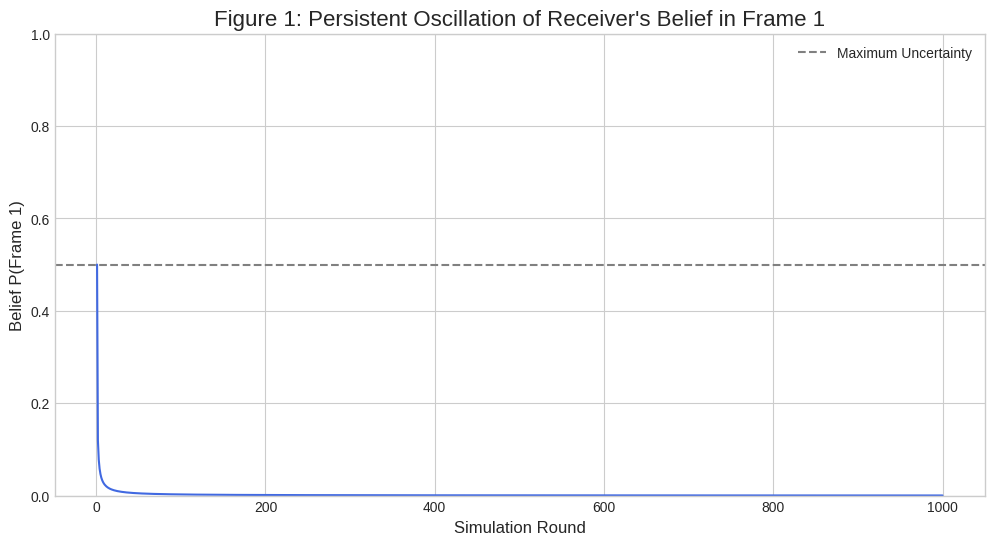

/tmp/ipython-input-2640022419.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=action_counts.index, y=action_counts.values, ax=ax, palette='viridis', order=action_order)


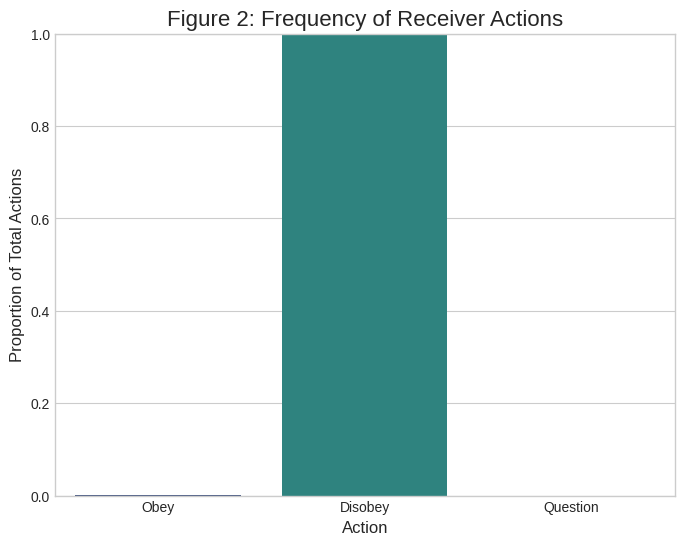


--- Table 1: Summary of Simulation Performance Metrics ---
                                        Value
Average Sender Payoff                  1.0090
Average Receiver Payoff                9.9800
Belief Oscillation Metric (E[p(1-p)])  0.0018
Frequency of 'Question'                0.0000


In [ ]:
# ==============================================================================
# 3. EXECUTION AND ANALYSIS
# ==============================================================================

# --- Define Analysis Functions First ---

def plot_belief_oscillation(results_df):
    """
    Plots the Receiver's belief in Frame 1 over time.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(x='round', y='receiver_belief_f1', data=results_df, ax=ax, color='royalblue')
    ax.set_title("Figure 1: Persistent Oscillation of Receiver's Belief in Frame 1", fontsize=16)
    ax.set_xlabel("Simulation Round", fontsize=12)
    ax.set_ylabel("Belief P(Frame 1)", fontsize=12)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, ls='--', color='gray', label='Maximum Uncertainty')
    ax.legend()
    plt.show()

def plot_action_frequency(results_df):
    """
    Plots the frequency of each action taken by the Receiver.
    """
    action_order = ['Obey', 'Disobey', 'Question']
    fig, ax = plt.subplots(figsize=(8, 6))
    action_counts = results_df['receiver_action'].value_counts(normalize=True).reindex(action_order, fill_value=0)
    sns.barplot(x=action_counts.index, y=action_counts.values, ax=ax, palette='viridis', order=action_order)
    ax.set_title("Figure 2: Frequency of Receiver Actions", fontsize=16)
    ax.set_xlabel("Action", fontsize=12)
    ax.set_ylabel("Proportion of Total Actions", fontsize=12)
    ax.set_ylim(0, 1)
    plt.show()

def generate_summary_table(results_df):
    """
    Calculates and prints a summary table of key performance metrics.
    """
    # Calculate belief oscillation metric: E[p(1-p)] is max (0.25) at p=0.5
    belief_oscillation = (results_df['receiver_belief_f1'] * (1 - results_df['receiver_belief_f1'])).mean()

    summary = {
        "Average Sender Payoff": results_df['sender_payoff'].mean(),
        "Average Receiver Payoff": results_df['receiver_payoff'].mean(),
        "Belief Oscillation Metric (E[p(1-p)])": belief_oscillation,
        "Frequency of 'Question'": (results_df['receiver_action'] == 'Question').mean()
    }
    summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
    print("\n--- Table 1: Summary of Simulation Performance Metrics ---")
    print(summary_df.round(4))
    return summary_df

# --- Simulation Parameters (Editable by User) ---
NUM_ROUNDS = 1000
LEARNING_RATE = 0.2  # Alpha
TEMPERATURE = 0.1    # Tau

# --- Instantiate and Run ---
# 1. Create the game environment and verify its structure
bateson_game = BatesonGame()
bateson_game.verify_axioms()

# 2. Create the agents
sender = RationalSender(bateson_game)
receiver = BoundedlyRationalReceiver(bateson_game, learning_rate=LEARNING_RATE, temperature=TEMPERATURE)

# 3. Run the simulation
simulation = Simulation(bateson_game, sender, receiver, num_rounds=NUM_ROUNDS)
results_df = simulation.run()

print(f"\nSimulation complete. Ran for {NUM_ROUNDS} rounds.")
print("Displaying results...")

# --- Generate Analytical Outputs ---
plot_belief_oscillation(results_df)
plot_action_frequency(results_df)
summary_df = generate_summary_table(results_df)